In [30]:
%matplotlib widget

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import tqdm

from bscarlos.settings import RAW_DATA_FOLDER#, PROCESSED_DATA_FOLDER
from bscarlos.detector import ClusteringDetector

In [31]:
data_attributes = pd.read_csv(RAW_DATA_FOLDER / 'data_attributes.csv').set_index("unique_patient_id")
data_attributes.head()

,patient_id,start_sample,end_sample,sample_rate
unique_patient_id,,,,
Pat00,P1,4185435,4918141,200.0
Pat01,P2,12681997,13408848,200.0
Pat02,P3,39835,764218,200.0
Pat03,P4,10844009,11573448,200.0
Pat04,P5,901647,1624579,200.0


In [32]:
data_files = sorted(list(RAW_DATA_FOLDER.glob('*.parquet')))

### Create `patient_data` dictionary
store all relavant information for BSUPP Algorithm

In [33]:
patient_data = {}

for file in tqdm.tqdm(data_files):
    patient_id = file.stem.split("-")[0]
    data = pd.read_parquet(file)
    
    fs = data_attributes.loc[patient_id, "sample_rate"]
    patient_data[patient_id] = {'data': data, 'fs': fs}

100%|██████████| 30/30 [00:05<00:00,  5.42it/s]


In [34]:
for key in patient_data.keys():
    print(key)

Pat00
Pat01
Pat02
Pat03
Pat04
Pat05
Pat06
Pat07
Pat08
Pat09
Pat10
Pat11
Pat12
Pat13
Pat14
Pat15
Pat16
Pat17
Pat18
Pat19
Pat20
Pat21
Pat22
Pat23_1
Pat24_2
Pat26
Pat27
Pat28
Pat29
Pat30


check frequency (`fs`) of Pat18

In [35]:
print(patient_data['Pat18']['fs'])

200.0


The data of each patient in this case Pat18 is in the form of a dataframe with 7 columns, the first 6 being the six derived montage bipolar channels with the seventh column being the labelled 'ground_truth' 0=no burst and 1=burst.

The 0-5 channels correspond to eight electrodes [Fp1, Fp2, F7, F8, T3, T4, T5, T6] with the following derivations:

- 0 : [Fp1-F7]
- 1 : [F7-T3]
- 2 : [T5-T3]
- 3 : [Fp2-F8]
- 4 : [F8-T4]
- 5 : [T6-T4]

In [36]:
patient_data['Pat18']['data']

,0,1,2,3,4,5,ground_truth
0,-8.450123e-18,-2.154055e-18,-1.221285e-17,-1.441472e-16,6.321814e-17,-1.812463e-16,0.0
1,-3.361786e-16,-7.681807e-17,-4.346179e-16,-5.130186e-15,2.250928e-15,-6.453078e-15,0.0
2,-6.580318e-15,-1.380954e-15,-7.746625e-15,-9.104520e-14,3.994469e-14,-1.145269e-13,0.0
3,-8.478600e-14,-1.669664e-14,-9.226504e-14,-1.075543e-12,4.716053e-13,-1.352534e-12,0.0
4,-8.113402e-13,-1.527649e-13,-8.265175e-13,-9.525758e-12,4.172258e-12,-1.197164e-11,0.0
...,...,...,...,...,...,...,...
724778,3.537972e+00,-4.507960e-01,-1.268837e+00,-1.667788e+00,1.530463e+00,6.990180e-01,0.0
724779,3.231484e+00,-4.678173e-01,-1.107772e+00,-1.737256e+00,1.471539e+00,8.739945e-01,0.0
724780,2.951274e+00,-4.342440e-01,-9.895223e-01,-1.765309e+00,1.429984e+00,9.700599e-01,0.0
724781,2.715492e+00,-3.542246e-01,-9.183520e-01,-1.762698e+00,1.398713e+00,9.807137e-01,0.0


### Create Learning and Testing Data
Seprating data based on:
- Learning period == First 15min Window
- Testing period >= 15min

In [37]:
# set Index to a Timedelta Index
for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    data = patient_info['data']
    fs = patient_info['fs']

    Ts = pd.Timedelta('1s') / fs
    data.index = data.index * Ts
    patient_data[patient_id]['data'] = data

    # calculate learning period as a Timedelta
    learning_period = pd.Timedelta(seconds=60 * 15)  # 15 minutes in new units

    # split the data using the Timedelta
    data_learning = data[data.index < learning_period]
    data_testing = data[data.index >= learning_period]

    # store the learning and testing data back in the dictionary
    patient_data[patient_id]['data_learning'] = data_learning
    patient_data[patient_id]['data_testing'] = data_testing

100%|██████████| 30/30 [00:03<00:00,  9.85it/s]


In [38]:
patient_data[patient_id].keys()

dict_keys(['data', 'fs', 'data_learning', 'data_testing'])

In [39]:
print(patient_data['Pat18']['data_learning'])
print(patient_data['Pat18']['data_testing'])
print(patient_data['Pat18']['data_learning']['ground_truth'])
print(f'Learning data shape:', patient_data['Pat18']['data_learning'].shape)
print(f'Testing data shape:', patient_data['Pat18']['data_testing'].shape)


                                   0             1             2  \
0 days 00:00:00        -8.450123e-18 -2.154055e-18 -1.221285e-17   
0 days 00:00:00.005000 -3.361786e-16 -7.681807e-17 -4.346179e-16   
0 days 00:00:00.010000 -6.580318e-15 -1.380954e-15 -7.746625e-15   
0 days 00:00:00.015000 -8.478600e-14 -1.669664e-14 -9.226504e-14   
0 days 00:00:00.020000 -8.113402e-13 -1.527649e-13 -8.265175e-13   
...                              ...           ...           ...   
0 days 00:14:59.975000  7.103343e-01  9.816785e-01 -5.224580e-01   
0 days 00:14:59.980000  6.489217e-01  1.000220e+00 -6.246476e-01   
0 days 00:14:59.985000  5.386150e-01  9.711927e-01 -6.624554e-01   
0 days 00:14:59.990000  3.998571e-01  9.019789e-01 -6.292273e-01   
0 days 00:14:59.995000  2.553404e-01  8.081338e-01 -5.299462e-01   

                                   3             4             5  ground_truth  
0 days 00:00:00        -1.441472e-16  6.321814e-17 -1.812463e-16           0.0  
0 days 00:00:00.00500

### Create EEG-only Data 
Dropping 'ground_truth' column from learning and testing datasets


In [40]:
for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    data = patient_info['data']  # Retrieve the patient's data
    fs = patient_info['fs']  # Retrieve the sample rate for this patient
    
    # Drop 'ground_truth' column from learning and testing datasets
    eeg_learning = data_learning.drop(columns = 'ground_truth')
    eeg_testing = data_testing.drop(columns = 'ground_truth')
    
    patient_data[patient_id]['eeg_learning'] = eeg_learning
    patient_data[patient_id]['eeg_testing'] = eeg_testing

100%|██████████| 30/30 [00:05<00:00,  5.24it/s]


In [121]:
print(patient_data['Pat18']['eeg_learning'])
print(patient_data['Pat18']['eeg_testing'])
# double check the dropped ground_truth column
print(patient_data['Pat18']['data_learning'].shape)
print(patient_data['Pat18']['eeg_learning'].shape)

print(patient_data['Pat18']['data_testing'].shape)
print(patient_data['Pat18']['eeg_testing'].shape)

                                      0             1             2  \
0 days 00:00:00            4.365609e-18 -3.723809e-18 -3.863532e-18   
0 days 00:00:00.003906250  1.572161e-16 -1.343338e-16 -1.391230e-16   
0 days 00:00:00.007812500  2.826450e-15 -2.419508e-15 -2.500843e-15   
0 days 00:00:00.011718750  3.386811e-14 -2.904837e-14 -2.996117e-14   
0 days 00:00:00.015625     3.046886e-13 -2.618625e-13 -2.694792e-13   
...                                 ...           ...           ...   
0 days 00:14:59.980468750  7.805870e-01 -6.009860e-01  8.801262e-01   
0 days 00:14:59.984375     1.332062e+00 -8.749943e-01  1.421350e+00   
0 days 00:14:59.988281250  1.656675e+00 -1.086844e+00  1.770061e+00   
0 days 00:14:59.992187500  1.734151e+00 -1.221201e+00  1.907011e+00   
0 days 00:14:59.996093750  1.572239e+00 -1.271722e+00  1.836429e+00   

                                      3             4             5  
0 days 00:00:00           -1.944335e-18  1.419736e-18  5.130853e-18  
0 days 

### Apply Clustering Detector on ALL patients

In [42]:
detector_results = pd.DataFrame(columns=['patient_id', 'predictions', 'labels', 'cov_matrices', 'metric_d'])

for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    detector = ClusteringDetector()
    eeg_learning = patient_info['eeg_learning']
    eeg_testing = patient_info['eeg_testing']

    detector.fit(eeg_learning)
    predictions = detector.predict(eeg_testing)

    detector_results = detector_results._append({
        'patient_id': patient_id,
        'predictions': predictions,
        'labels': detector.labels_,
        'cov_matrices': detector.cov_matrices_,
        'metric_d': detector.metric_d_
    }, ignore_index=True)


  0%|          | 0/30 [00:00<?, ?it/s]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
100%|██████████| 30/30 [15:35<00:00, 31.19s/it]


In [43]:
patient_data[patient_id].keys()

dict_keys(['data', 'fs', 'data_learning', 'data_testing', 'eeg_learning', 'eeg_testing'])

In [44]:
print(detector_results.keys())
print(detector_results.head(-1))

Index(['patient_id', 'predictions', 'labels', 'cov_matrices', 'metric_d'], dtype='object')
   patient_id                                        predictions  \
0       Pat00  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1       Pat01  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2       Pat02  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       Pat03  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       Pat04  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
5       Pat05  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
6       Pat06  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
7       Pat07  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
8       Pat08  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
9       Pat09  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
10      Pat10  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
11      Pat11  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
12      Pat12  [0, 0, 0, 

In [57]:
detector_results.loc[detector_results['patient_id'] == 'Pat18', 'labels'].values[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

#### Visualize EEG
Plot the EEG data for each patient, along with the predicted labels. To see how the detector is labeling different segments of the data.


In [45]:
def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    plt.figure()

    for i, col in enumerate(df):

        scale = 1
        if str(col) not in {'0', '1', '2', '3', '4', '5'}:
            scale = 50

        x = df[col].to_numpy()
        plt.plot(t_s, scale*x+100*i, label=col)

    plt.xlabel('time [s]')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()

In [49]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

##### Plotting LEARNED labels for Pat18

In [113]:
data_learning = patient_data['Pat18']['data_learning']
eeg_learning = detector.get_windows(patient_data['Pat18']['eeg_learning'])
learned_labels = detector_results.loc[detector_results['patient_id'] == 'Pat18', 'labels'].values[0]

labels_frame = combine_windows_with_labels(eeg_learning, learned_labels)
data_learning_labeled = data_learning.copy()
data_learning_labeled['label'] = labels_frame['label']

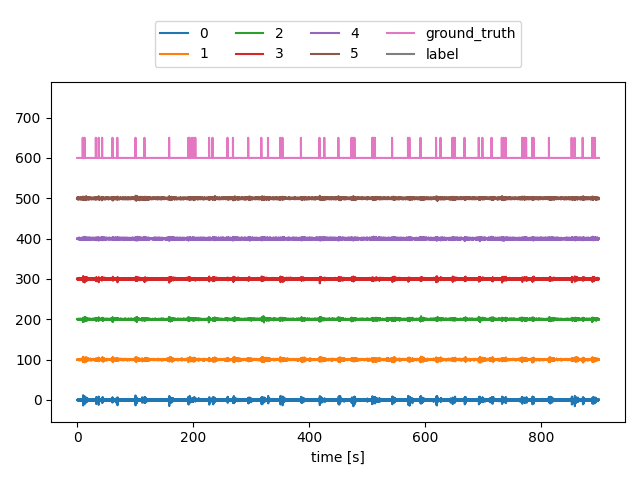

In [114]:
plot_eeg(data_learning_labeled)

##### Plotting LEARNED labels for Pat19

In [115]:
data_learning = patient_data['Pat19']['data_learning']
eeg_learning = detector.get_windows(patient_data['Pat19']['eeg_learning'])
learned_labels = detector_results.loc[detector_results['patient_id'] == 'Pat19', 'labels'].values[0]

labels_frame = combine_windows_with_labels(eeg_learning, learned_labels)
data_learning_labeled = data_learning.copy()
data_learning_labeled['label'] = labels_frame['label']

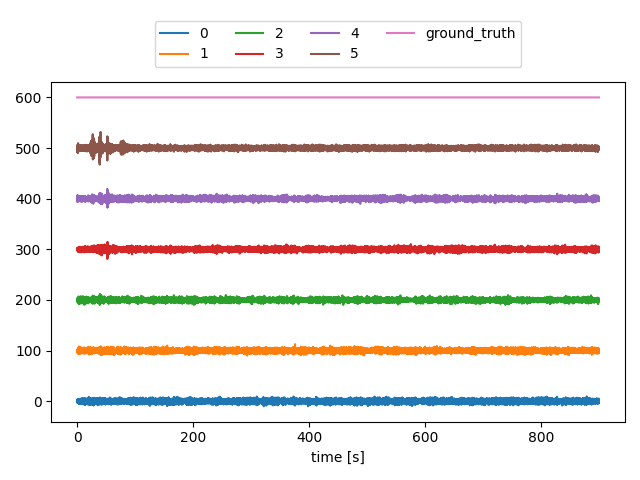

In [120]:
plot_eeg(data_learning)

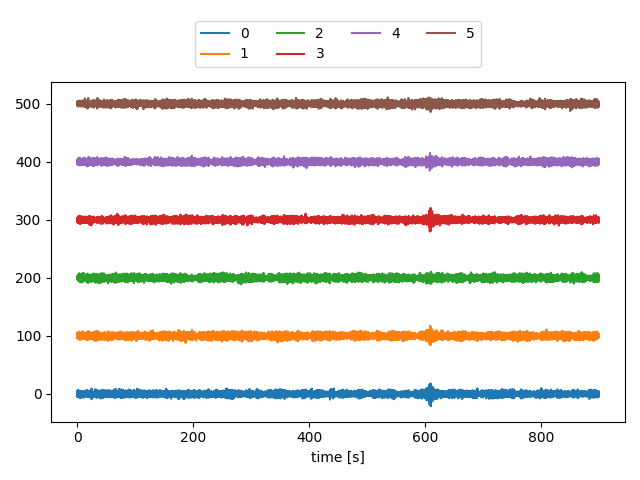

In [119]:
plot_eeg(patient_data['Pat19']['eeg_learning'])

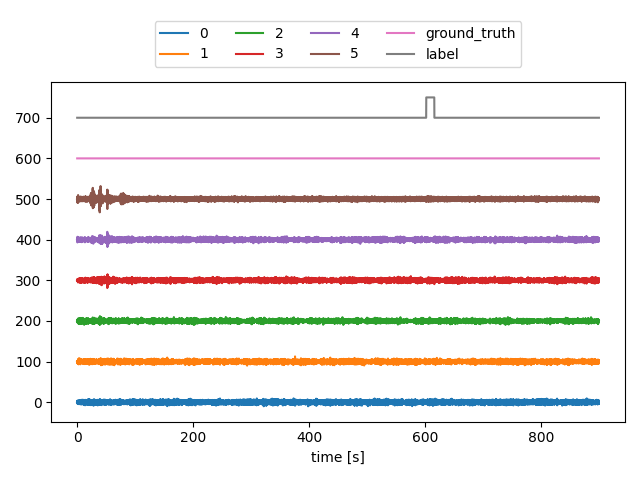

In [116]:
plot_eeg(data_learning_labeled)

#### Plot Predicted Labels

In [100]:
data_testing = patient_data['Pat18']['data_testing']
eeg_testing = detector.get_windows(patient_data['Pat18']['eeg_testing'])
predicted_labels = detector_results.loc[detector_results['patient_id'] == 'Pat18', 'predictions'].values[0]

labels_frame = combine_windows_with_labels(eeg_testing, predicted_labels)
data_testing_labeled = data_testing.copy()
data_testing_labeled['label'] = labels_frame['label']

In [107]:
print(predicted_labels.shape)

(3188,)


In [ ]:
print

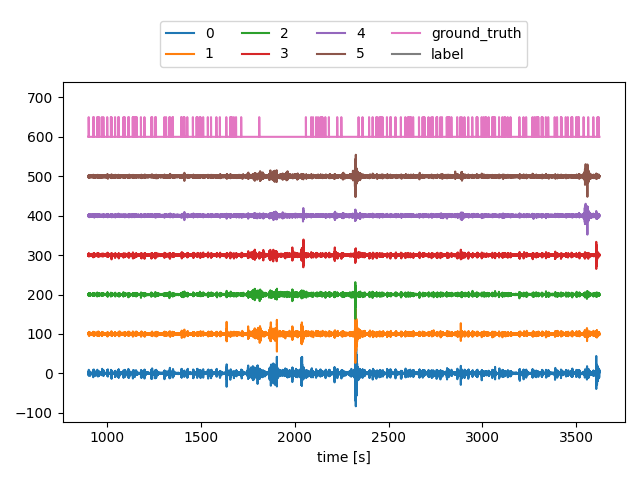

In [102]:
plot_eeg(data_testing_labeled)

In [103]:
data_testing = patient_data['Pat19']['data_testing']
eeg_testing = detector.get_windows(patient_data['Pat19']['eeg_testing'])
predicted_labels = detector_results.loc[detector_results['patient_id'] == 'Pat19', 'predictions'].values[0]

labels_frame = combine_windows_with_labels(eeg_testing, predicted_labels)
data_testing_labeled = data_testing.copy()
data_testing_labeled['label'] = labels_frame['label']

In [105]:
print(predicted_labels)

[0 0 0 ... 0 0 0]


C:\Users\c_arz\AppData\Local\Temp\ipykernel_30672\4196342895.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


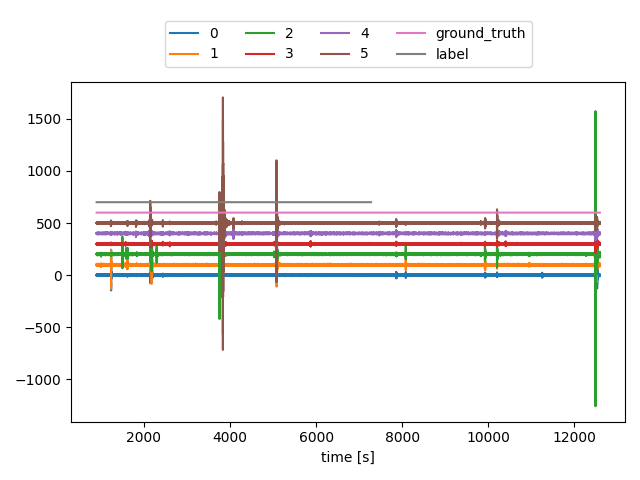

In [104]:
plot_eeg(data_testing_labeled)

#### Confusion matrix: 
Obtatining the confusion matrix to evaluate the performance of the detector.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cf = ConfusionMatrixDisplay.from_predictions(data_testing_cropped_labeled['ground_truth'], data_testing_cropped_labeled['label'])

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    detector_results = patient_info['detector_results']
    predictions = detector_results['predictions']
    labels = detector_results['labels']

    cm = confusion_matrix(labels, predictions)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Patient {patient_id} - Confusion Matrix')
    plt.show()

#### TO DO: Combine windows with labels

In [ ]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

#### TO DO: Save 'detector results' in data folder

In [ ]:
def save_results_as_parquet(results_dict, base_folder):
    for patient_id, results in results_dict.items():
        # Assuming 'results' can be directly converted to a DataFrame
        # You might need to adjust this part if 'results' requires preprocessing
        df = pd.DataFrame(results)
        
        # Construct the filename and path
        filename = f"{patient_id}-detector_results.parquet"
        filepath = f"{base_folder}/data/{filename}"
        
        # Save the DataFrame as a Parquet file
        df.to_parquet(filepath, index=False)


base_folder = "/burst-suppression-carlos/data/detector_results"  # Adjust this to your base folder path
save_results_as_parquet(results_for_analysis, base_folder)

NameError: name 'results_for_analysis' is not defined

#### TO DO: Store patient `info[detector results]` AS PARQUET FILE

In [ ]:
results_for_analysis = {}

for patient_id, info in patient_data.items():
    detector_results = info.get('detector_results')
    if detector_results:
        results_for_analysis[patient_id] = {
            'predictions': detector_results['predictions'],
            'labels': detector_results['labels'],
            'cov_matrices': detector_results['cov_matrices'],
            'metric_d': detector_results['metric_d']
        }


In [ ]:
for keys in results_for_analysis.keys():
    print(keys)


In [ ]:
print(results_for_analysis['Pat10']['predictions'].shape)
print(results_for_analysis['Pat10']['labels'].shape)

print(results_for_analysis['Pat10']['labels'])
print(results_for_analysis['Pat10']['cov_matrices'])

#### Calculate AUROC 

In [ ]:
from sklearn.metrics import roc_auc_score

auroc_scores = {}

for patient_id, results in results_for_analysis.items():
    true_labels = results['labels']
    predictions = results['predictions']
    auroc = roc_auc_score(true_labels, predictions)
    auroc_scores[patient_id] = auroc

In [ ]:
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(true_labels, predicted_scores)
auroc = auc(fpr, tpr)
print(f"AUROC: {auroc:.2f}")

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for patient_id, results in results_for_analysis.items():
    true_labels = results['labels']
    scores = results['predictions']
    
    fpr, tpr, _ = roc_curve(true_labels, scores)
    plt.plot(fpr, tpr, label=f'Patient {patient_id} (AUROC = {auroc_scores[patient_id]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()

#### Calculate Burst Per Minute (BPM)
```
# Calculate Bursts Per Minute (BPM)
def calculate_bpm(data, bursts_column, window_size_seconds=2, sample_rate=200):
    total_eeg_duration = (len(data) / sample_rate / 60)
    bursts = []
    in_burst = False
    window_start_time = None

    for i, row in data.iterrows():
        if row[bursts_column] == 1 and not in_burst:
            # Start of a new burst
            in_burst = True
            window_start_time = i 
            bursts.append(i)
        elif row[bursts_column] == 0 and in_burst:
            # End of a burst
            in_burst = False
        elif in_burst and (i - window_start_time).total_seconds() >= window_size_seconds:
            # Still in a burst, but outside the current window
            in_burst = False

    total_bursts = len(bursts)

    bpm = total_bursts / total_eeg_duration
    return bpm
```

In [ ]:
# data_testing

to do: 
- [ ] save calculated predictions as parquet file
- [ ] plot results for a couple of patients from patient_data dictionary
- [ ] widen ground truth by 2s
- [ ] compare results in all patients:
    - [ ] check in which direction to fill bfill() method
    - [ ] extend ground truth by fill forward ffill() method
    - [ ] visually inspect to see which direction
- [ ] calculate the difference between (.labels_ - ground_truth)=False positves and (ground_truth - labels_)=False negatives
- [ ] research literature to see validation methods; send to Jenny
- [ ] run rf on all patients
- [ ] compare clusteringdector to rf